In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from utils import RAT

In [ ]:

# def get_grid_metrics(rat_x, rat_y, spike_x, spike_y):
#     """
#     Simplistic helper to find L (scale) and theta (orientation).
#     In a real scenario, you'd pull this from a 2D autocorrelation.
#     For now, we will assume standard values or placeholders.
#     """
#     # Placeholder: Usually extracted via peak-finding on 2D autocorrelation
#     L = 40.0         # Grid scale in cm
#     theta = np.radians(15) # Grid orientation in radians
#     return L, theta

# def calculate_grid_phase(spike_x, spike_y, L, theta):
#     """
#     Converts (x, y) coordinates into grid phase (phi1, phi2).
#     """
#     # Basis vectors for the hexagonal lattice
#     u1 = np.array([L * np.cos(theta), L * np.sin(theta)])
#     u2 = np.array([L * np.cos(theta + np.pi/3), L * np.sin(theta + np.pi/3)])
    
#     # Generator matrix
#     G = np.column_stack([u1, u2])
#     G_inv = np.linalg.inv(G)
    
#     # Transform all spikes
#     pos = np.vstack([spike_x, spike_y])
#     phases = np.dot(G_inv, pos)
    
#     # Return wrapped phase [0, 1)
#     return phases % 1

# def run_phase_analysis(cell_id, spike_stamps, t, x, y):
#     # 1. Get position at spike times
#     spike_x = np.interp(spike_stamps, t, x)
#     spike_y = np.interp(spike_stamps, t, y)
    
#     # 2. Define Geometry (L and Theta)
#     # Ideally, you'd calculate this once per module, not per cell.
#     L, theta = get_grid_metrics(x, y, spike_x, spike_y)
    
#     # 3. Calculate Phases
#     phases = calculate_grid_phase(spike_x, spike_y, L, theta)
    
#     # 4. Split into Early and Late
#     t_start = t[0]
#     t_end = t[-1]
    
#     early_mask = (spike_stamps <= t_start + 120)
#     late_mask = (spike_stamps >= t_end - 120)
    
#     early_phases = phases[:, early_mask]
#     late_phases = phases[:, late_mask]
    
#     # 5. Plotting in Rhombic Phase Space
#     fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    
#     ax[0].scatter(early_phases[0], early_phases[1], s=10, color='blue', alpha=0.5)
#     ax[0].set_title(f'First 2 Mins - Cell {cell_id}')
#     ax[0].set_xlabel('Phase 1')
#     ax[0].set_ylabel('Phase 2')
    
#     ax[1].scatter(late_phases[0], late_phases[1], s=10, color='red', alpha=0.5)
#     ax[1].set_title(f'Last 2 Mins - Cell {cell_id}')
#     ax[1].set_xlabel('Phase 1')
    
#     plt.tight_layout()
#     plt.show()



In [5]:

RAT_ID = 2

LIGHTING = "light"

rat = RAT(n=RAT_ID, lighting=LIGHTING, filter_speed=False)

t = rat.T # (s), starts at 0

x = rat.X # (cm)

y = rat.Y # (cm)


v = rat.V # (cm/s)

spikes_by_cell = {}

spikes_by_cell.update(rat.grid_mod1)

spikes_by_cell.update(rat.grid_mod2)

spikes_by_cell.update(rat.grid_mod3) 

Drift Distance: 2.74 cm
Path Straightness (Late): 0.066


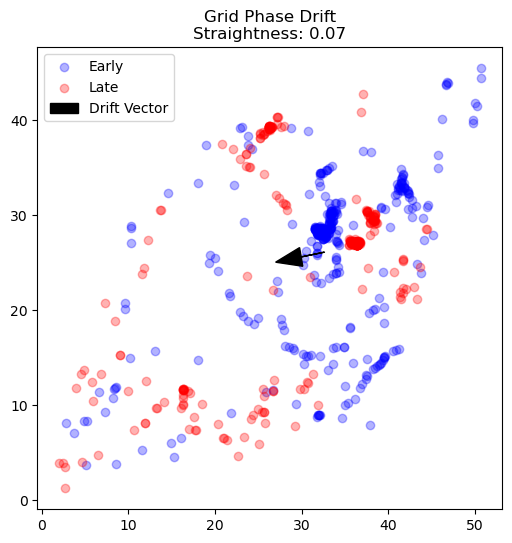

In [ ]:


# def get_phase_vector(spike_x, spike_y, L, theta):
#     """Converts spatial spikes to 2D phase Cartesian coordinates."""
#     # Basis vectors
#     u1 = np.array([L * np.cos(theta), L * np.sin(theta)])
#     u2 = np.array([L * np.cos(theta + np.pi/3), L * np.sin(theta + np.pi/3)])
#     G = np.column_stack([u1, u2])
#     G_inv = np.linalg.inv(G)
    
#     # Project and wrap
#     phases = np.dot(G_inv, np.vstack([spike_x, spike_y])) % 1
    
#     # Convert back to Cartesian for intuitive distance measuring
#     # This maps the [0,1] rhombic phase back into cm-scale space
#     cart_phases = phases[0,:] * u1[:,None] + phases[1,:] * u2[:,None]
#     return cart_phases

# def calculate_straightness(x, y, window_t):
#     """Calculates displacement/distance ratio. 1.0 is a perfectly straight line."""
#     dx = np.diff(x)
#     dy = np.diff(y)
#     dist_traveled = np.sum(np.sqrt(dx**2 + dy**2))
#     displacement = np.sqrt((x[-1] - x[0])**2 + (y[-1] - y[0])**2)
#     return displacement / dist_traveled if dist_traveled > 0 else 0

# # --- Analysis Parameters ---
# L = 40.0         # Grid scale (cm)
# theta = 0.2      # Grid angle (rad)
# WINDOW_SIZE = 120 # 2-minute windows

# results = []

# for cell_id, stamps in spikes_by_cell.items():
#     if len(stamps) < 200: continue
    
#     # Get spatial data for early and late windows
#     for label, t_range in [("Early", (t[0], t[0]+WINDOW_SIZE)), 
#                            ("Late", (t[-1]-WINDOW_SIZE, t[-1]))]:
        
#         # Filter trajectory and spikes for this window
#         mask_t = (t >= t_range[0]) & (t <= t_range[1])
#         mask_s = (stamps >= t_range[0]) & (stamps <= t_range[1])
        
#         window_x, window_y = x[mask_t], y[mask_t]
#         s_x = np.interp(stamps[mask_s], t, x)
#         s_y = np.interp(stamps[mask_s], t, y)
        
#         # Calculate Phase and Straightness
#         p_coords = get_phase_vector(s_x, s_y, L, theta)
#         avg_phase = np.mean(p_coords, axis=1)
#         straightness = calculate_straightness(window_x, window_y, WINDOW_SIZE)
        
#         results.append({
#             'cell': cell_id,
#             'period': label,
#             'avg_phase': avg_phase,
#             'straightness': straightness,
#             'phases': p_coords
#         })

# # --- Compare Scenario A vs B ---
# # Calculate drift distance (Euclidean distance between Early and Late avg_phase)
# early = results[0]
# late = results[1]
# drift_dist = np.linalg.norm(late['avg_phase'] - early['avg_phase'])

# print(f"Drift Distance: {drift_dist:.2f} cm")
# print(f"Path Straightness (Late): {late['straightness']:.3f}")

# # Visualization
# fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# ax.scatter(early['phases'][0], early['phases'][1], alpha=0.3, label='Early', c='blue')
# ax.scatter(late['phases'][0], late['phases'][1], alpha=0.3, label='Late', c='red')
# ax.arrow(early['avg_phase'][0], early['avg_phase'][1], 
#          late['avg_phase'][0]-early['avg_phase'][0], 
#          late['avg_phase'][1]-early['avg_phase'][1], 
#          head_width=2, color='black', label='Drift Vector')

# ax.set_title(f"Grid Phase Drift\nStraightness: {late['straightness']:.2f}")
# ax.legend()
# plt.show()

In [11]:
import numpy as np
from scipy import signal, ndimage

def get_rate_map(spike_x, spike_y, rat_x, rat_y, bin_size=2, sigma=2):
    """Creates a smoothed 2D spatial firing rate map."""
    # Define arena bounds
    x_bins = np.arange(np.min(rat_x), np.max(rat_x), bin_size)
    y_bins = np.arange(np.min(rat_y), np.max(rat_y), bin_size)
    
    # Occupancy map (time spent in each bin)
    occ, _, _ = np.histogram2d(rat_x, rat_y, bins=[x_bins, y_bins])
    # Spike map (count spikes in each bin)
    spk, _, _ = np.histogram2d(spike_x, spike_y, bins=[x_bins, y_bins])
    
    # Calculate rate and smooth
    rate_map = np.divide(spk, occ, out=np.zeros_like(spk), where=occ > 0)
    rate_map = ndimage.gaussian_filter(rate_map, sigma=sigma)
    return rate_map

def extract_grid_geometry(rate_map, bin_size=2):
    """Calculates L and theta from the 2D autocorrelogram."""
    # 1. 2D Autocorrelation
    rm_mean = rate_map - np.mean(rate_map)
    autocorr = signal.correlate2d(rm_mean, rm_mean, mode='full')
    
    # 2. Find peaks
    # We look for the 6 closest peaks to the center
    center = np.array(autocorr.shape) // 2
    local_max = ndimage.maximum_filter(autocorr, size=5) == autocorr
    peaks = np.argwhere(local_max & (autocorr > 0.1 * np.max(autocorr)))
    
    # 3. Calculate distances and angles from center
    dist_to_center = np.linalg.norm(peaks - center, axis=1)
    
    # Filter out the center peak itself
    mask = (dist_to_center > 2) 
    peaks, dist_to_center = peaks[mask], dist_to_center[mask]
    
    # Get the 6 closest peaks
    closest_idx = np.argsort(dist_to_center)[:6]
    six_peaks = peaks[closest_idx]
    
    # 4. Compute L and Theta
    L_pix = np.mean(dist_to_center[closest_idx])
    L = L_pix * bin_size # Convert pixels to cm
    
    # Angles relative to center
    dy_dx = six_peaks - center
    angles = np.arctan2(dy_dx[:, 0], dy_dx[:, 1])
    
    # Grid orientation is usually the smallest positive angle modulo 60 degrees
    theta = np.min(angles[angles > 0]) % (np.pi/3)
    
    return L, theta, autocorr

# --- Execution ---
# Let's take one cell's spikes
cell_id = list(spikes_by_cell.keys())[0]
stamps = spikes_by_cell[cell_id]
s_x = np.interp(stamps, t, x)
s_y = np.interp(stamps, t, y)

rm = get_rate_map(s_x, s_y, x, y)
L, theta, ac = extract_grid_geometry(rm)

print(f"Cell {cell_id} | Scale L: {L:.2f} cm | Orientation: {np.degrees(theta):.2f}°")

Cell 644 | Scale L: 48.96 cm | Orientation: 59.53°


/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Skipping Cell 357: Could not extract geometry. zero-size array to reduction operation minimum which has no identity
Skipping Cell 395: Could not extract geometry. zero-size array to reduction operation minimum which has no identity
Skipping Cell 414: Could not extract geometry. zero-size array to reduction operation minimum which has no identity


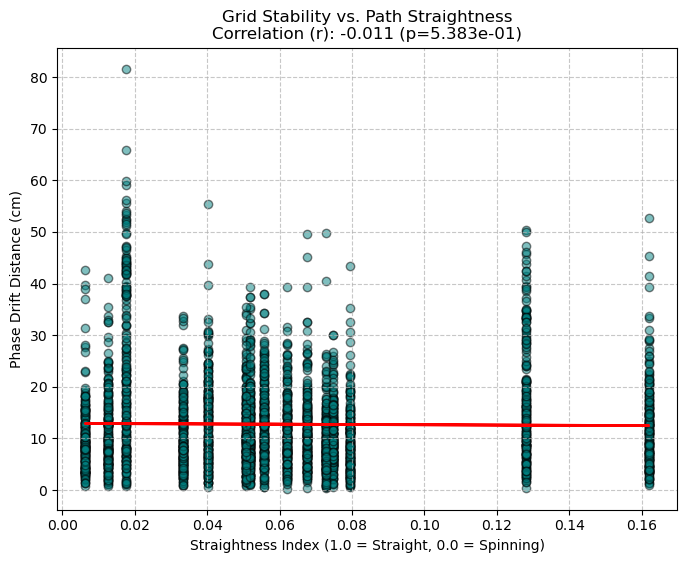

In [ ]:
# from scipy.stats import pearsonr

# def analyze_all_cells_with_geometry(spikes_by_cell, t, x, y, window_sec=120):
#     all_drift = []
#     all_straightness = []

#     for cell_id, stamps in spikes_by_cell.items():
#         if len(stamps) < 500: 
#             continue # Only high-quality cells
        
#         # 1. Get spatial data for the whole session for this cell
#         s_x_full = np.interp(stamps, t, x)
#         s_y_full = np.interp(stamps, t, y)
        
#         # 2. Dynamically calculate L and theta for THIS specific cell
#         try:
#             rm = get_rate_map(s_x_full, s_y_full, x, y)
#             L, theta, _ = extract_grid_geometry(rm)
#         except Exception as e:
#             print(f"Skipping Cell {cell_id}: Could not extract geometry. {e}")
#             continue

#         # 3. Setup Basis for this cell's specific geometry
#         u1 = np.array([L * np.cos(theta), L * np.sin(theta)])
#         u2 = np.array([L * np.cos(theta + np.pi/3), L * np.sin(theta + np.pi/3)])
#         G = np.column_stack([u1, u2])
#         G_inv = np.linalg.inv(G)

#         # 4. Convert all spikes for this cell into Phase Space
#         phases = np.dot(G_inv, np.vstack([s_x_full, s_y_full])) % 1
#         # Convert to Cartesian phase (cm) for distance measuring
#         cart_phases = phases[0,:] * u1[:,None] + phases[1,:] * u2[:,None]

#         # 5. Get "Anchor Phase" (First 2 minutes)
#         early_mask = (stamps <= t[0] + window_sec)
#         if np.sum(early_mask) < 20: 
#             continue
#         anchor_phase = np.mean(cart_phases[:, early_mask], axis=1)

#         # 6. Slide through the session in windows
#         session_duration = t[-1] - t[0]
#         # range(start, stop, step)
#         for start_t in range(int(t[0]) + window_sec, int(t[-1]) - window_sec, window_sec):
#             end_t = start_t + window_sec
            
#             # Mask spikes and trajectory
#             s_mask = (stamps >= start_t) & (stamps < end_t)
#             t_mask = (t >= start_t) & (t < end_t)
            
#             if np.sum(s_mask) < 20: 
#                 continue 
            
#             # Calculate Straightness Index
#             win_x, win_y = x[t_mask], y[t_mask]
#             dx, dy = np.diff(win_x), np.diff(win_y)
#             dist_trav = np.sum(np.sqrt(dx**2 + dy**2))
#             displace = np.sqrt((win_x[-1]-win_x[0])**2 + (win_y[-1]-win_y[0])**2)
            
#             straightness = displace / dist_trav if dist_trav > 0 else 0
            
#             # Calculate Drift magnitude (Euclidean distance in cm)
#             current_phase = np.mean(cart_phases[:, s_mask], axis=1)
#             drift = np.linalg.norm(current_phase - anchor_phase)
            
#             all_drift.append(drift)
#             all_straightness.append(straightness)

#     return np.array(all_straightness), np.array(all_drift)

# # --- Execute and Plot ---
# # Note: Use your actual L and theta derived from the rat's grid module
# straightness_vals, drift_vals = analyze_all_cells_with_geometry(spikes_by_cell, t, x, y)

# # Calculate Pearson Correlation
# r_val, p_val = pearsonr(straightness_vals, drift_vals)

# plt.figure(figsize=(8, 6))
# plt.scatter(straightness_vals, drift_vals, alpha=0.5, c='teal', edgecolors='k')
# plt.title(f"Grid Stability vs. Path Straightness\nCorrelation (r): {r_val:.3f} (p={p_val:.3e})")
# plt.xlabel("Straightness Index (1.0 = Straight, 0.0 = Spinning)")
# plt.ylabel("Phase Drift Distance (cm)")
# plt.grid(True, linestyle='--', alpha=0.7)

# # Add a trendline
# m, b = np.polyfit(straightness_vals, drift_vals, 1)
# plt.plot(straightness_vals, m*straightness_vals + b, color='red', linewidth=2, label='Trendline')

# plt.show()

In [10]:
from scipy.ndimage import median_filter
from scipy.ndimage import gaussian_filter1d
from scipy import ndimage

In [11]:
def find_k(array , value):
        """Finds index of the closest value in an array."""
        return (np.abs(array-value)).argmin()
def rate_map(x, y, t ,spike, bin_width= 1 , margin = 0):
        """Computes the firing rate map using 2D histogram binning."""                             
        x_edges = np.arange(min(x) - margin, max(x)+margin , bin_width)
        y_edges = np.arange(min(y) - margin, max(y)+margin , bin_width)
        ind_x = [find_k(t, i) for i in spike]
        ind_y = [find_k(t, i) for i in spike]
        occ = np.histogram2d(x, y, bins = (x_edges , y_edges))[0]
        act = np.histogram2d(x[ind_x], y[ind_y], bins = (x_edges , y_edges))[0]
        rate = np.divide(act, occ, out=np.zeros_like(act), where=occ > 0.01)
        # rate = act / (occ*0.02)
        return rate
from scipy.ndimage import gaussian_filter

def extract_grid_geometry(rate_map, bin_size=1 , smoothing = 1.5):
    """Calculates L and theta from the 2D autocorrelogram."""
    # 1. 2D Autocorrelation
    if smoothing > 0:
        rate_map = gaussian_filter(rate_map, sigma=smoothing)
    rm_mean = rate_map - np.nanmean(rate_map)
    autocorr = signal.correlate2d(rm_mean, rm_mean, mode='full')
    
    # 2. Find peaks
    # We look for the 6 closest peaks to the center
    center = np.array(autocorr.shape) // 2
    local_max = ndimage.maximum_filter(autocorr, size=5) == autocorr
    peaks = np.argwhere(local_max & (autocorr > 0.1 * np.max(autocorr)))
    # plt.imshow(autocorr , aspect='auto')
    # plt.show()
    # print('autocoor' , np.unique(autocorr))
    # 3. Calculate distances and angles from center
    dist_to_center = np.linalg.norm(peaks - center, axis=1)
    
    # Filter out the center peak itself
    mask = (dist_to_center > 2) 
    peaks, dist_to_center = peaks[mask], dist_to_center[mask]
    
    # Get the 6 closest peaks
    closest_idx = np.argsort(dist_to_center)[:6]
    six_peaks = peaks[closest_idx]
#     print('closest_idx' , closest_idx)
    # 4. Compute L and Theta
    L_pix = np.mean(dist_to_center[closest_idx])
    L = L_pix * bin_size # Convert pixels to cm
#     print(six_peaks , center)
    # Angles relative to center
    dy_dx = six_peaks - center
    angles = np.arctan2(dy_dx[:, 0], dy_dx[:, 1])
#     print(np.unique(angles))
    # Grid orientation is usually the smallest positive angle modulo 60 degrees
    theta = np.min(angles[angles > 0]) % (np.pi/3)
    
    return L, theta, autocorr

# rm =  rate_map(x, y, t ,spikes_by_cell[711])
# extract_grid_geometry(rm)

In [20]:
dx = np.gradient(x)
dy = np.gradient(y)

sigma_smoothing = 2
x_smooth = gaussian_filter1d(x, sigma=sigma_smoothing)
y_smooth = gaussian_filter1d(y, sigma=sigma_smoothing)

# 2. Recalculate dx, dy from smoothed data
dx_s = np.gradient(x_smooth)
dy_s = np.gradient(y_smooth)

# 3. Recalculate angle and unwrap
move_angle_s = np.unwrap(np.arctan2(dy_s, dx_s))

# 4. Calculate omega from the smoothed angle
dt = np.median(np.diff(t))
omega_fixed = np.abs(np.gradient(move_angle_s) / dt)

# Apply a small median filter to omega itself just to be safe
omega_fixed = median_filter(omega_fixed, size=3)

# 5. Mask for movement only (Speed > 3 cm/s)
speed_mask = v > 3

omega_threshold = np.percentile(omega_fixed, 80) # Or a fixed value like 0.5

high_omega_mask = speed_mask & (omega_fixed > omega_threshold)
low_omega_mask = speed_mask & (omega_fixed <= omega_threshold)



In [6]:
def get_2d_phase(x, y, L, theta):
    v1 = np.array([np.cos(theta), np.sin(theta)])
    v2 = np.array([np.cos(theta + np.pi/3), np.sin(theta + np.pi/3)])
    A = L * np.vstack([v1, v2]).T 
    # 2. Invert the matrix to get the transformation from (x,y) to (phase1, phase2)
    A_inv = np.linalg.inv(A)
    
    # 3. Project all positions into "grid-scale" coordinates
    pos = np.vstack([x, y])
    grid_coords = A_inv @ pos
    
    # 4. Take the modulo 1 to wrap everything into the [0, 1] unit cell
    phi1 = grid_coords[0, :] % 1
    phi2 = grid_coords[1, :] % 1
    
    return phi1, phi2


def calculate_phase_coherence(phi1, phi2):
    # Convert [0, 1] to [0, 2*pi]
    alpha1 = phi1 * 2 * np.pi
    alpha2 = phi2 * 2 * np.pi
    
    # Calculate Mean Resultant Length for each dimension
    r1 = np.abs(np.mean(np.exp(1j * alpha1)))
    r2 = np.abs(np.mean(np.exp(1j * alpha2)))
    
    # Combined coherence metric
    return np.sqrt(r1**2 + r2**2)

In [66]:
from scipy.stats import circmean , circvar

cell_stats = {}

for cell_id, spike_times in spikes_by_cell.items():
    # 1. Get L and theta for this specific cell
    rm = rate_map(x, y, t ,spike_times) 
    # print('rate map', rm.shape , rm)
    try:
        L, theta , _ = extract_grid_geometry(rm) 
        # print("FOUND ONE!")
    except Exception as e:
            print(f"Skipping Cell {cell_id}: Could not extract geometry. {e}")
            continue

    # 2. Project trajectory onto grid axes
    # This allows you to see if the 'spatial phase' shifts 
    # during high omega segments
    # phase_x = (x_smooth * np.cos(theta) + y_smooth * np.sin(theta)) % L
    # phase_y = (x_smooth * np.cos(theta + np.pi/3) + y_smooth * np.sin(theta + np.pi/3)) % L
    
    # # 3. Separate spikes by turning vs straight
    # spk_idx = np.searchsorted(t, spike_times)
    # turning_spikes = phase_x[spk_idx[high_omega_mask[spk_idx]]]
    # straight_spikes = phase_x[spk_idx[low_omega_mask[spk_idx]]]

    # Calculate 2D phases for all spikes
    phi1, phi2 = get_2d_phase(x_smooth, y_smooth, L, theta)
    spk_idx = np.searchsorted(t, spike_times)
    spk_phi1 = phi1[spk_idx]
    spk_phi2 = phi2[spk_idx]

    # Separate them
    turning_phi1 = spk_phi1[high_omega_mask[spk_idx]]
    turning_phi2 = spk_phi2[high_omega_mask[spk_idx]]

    straight_phi1 = spk_phi1[low_omega_mask[spk_idx]]
    straight_phi2 = spk_phi2[low_omega_mask[spk_idx]]



    r_straight = calculate_phase_coherence(straight_phi1, straight_phi2)
    r_turn = calculate_phase_coherence(turning_phi1, turning_phi2)
    
    cell_stats[cell_id] = {
        'L': L,
        'theta': theta,
        'drift_metric': np.mean(r_turn) - np.mean(r_straight)
    }

/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Skipping Cell 718: Could not extract geometry. zero-size array to reduction operation minimum which has no identity
Skipping Cell 357: Could not extract geometry. zero-size array to reduction operation minimum which has no identity
Skipping Cell 382: Could not extract geometry. zero-size array to reduction operation minimum which has no identity
Skipping Cell 414: Could not extract geometry. zero-size array to reduction operation minimum which has no identity
Skipping Cell 453: Could not extract geometry. zero-size array to reduction operation minimum which has no identity
Skipping Cell 1034: Could not extract geometry. zero-size array to reduction operation minimum which has no identity
Skipping Cell 1106: Could not extract geometry. zero-size array to reduction operation minimum which has no identity


In [75]:
r_straight , r_turn

(np.float64(0.4277837538632409), np.float64(0.3593328458797894))

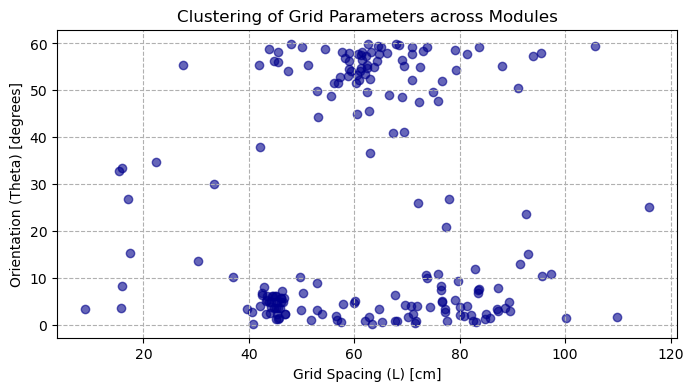

In [67]:
import matplotlib.pyplot as plt

# Extract data for plotting
Ls = [data['L'] for data in cell_stats.values()]
thetas = [np.degrees(data['theta']) % 60 for data in cell_stats.values()] # 60-deg symmetry

plt.figure(figsize=(8, 4))
plt.scatter(Ls, thetas, c='darkblue', alpha=0.6)
plt.xlabel('Grid Spacing (L) [cm]')
plt.ylabel('Orientation (Theta) [degrees]')
plt.title('Clustering of Grid Parameters across Modules')
plt.grid(True, linestyle='--')
plt.show()

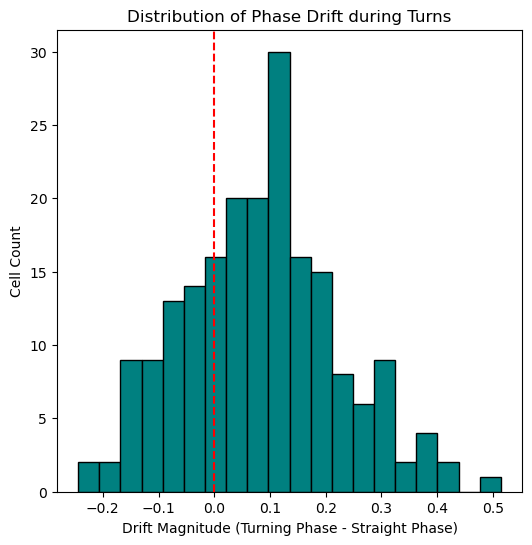

In [68]:
# Aggregate drift for all cells
all_drifts = [data['drift_metric'] for data in cell_stats.values()]

plt.figure(figsize=(6, 6))
plt.hist(all_drifts, bins=20, color='teal', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Phase Drift during Turns')
plt.xlabel('Drift Magnitude (Turning Phase - Straight Phase)')
plt.ylabel('Cell Count')
plt.show()

In [58]:
cell_stats[644]

{'L': np.float64(40.778602176106645),
 'theta': np.float64(0.004452661351776133),
 'drift_metric': np.float64(-1.622361702602678)}

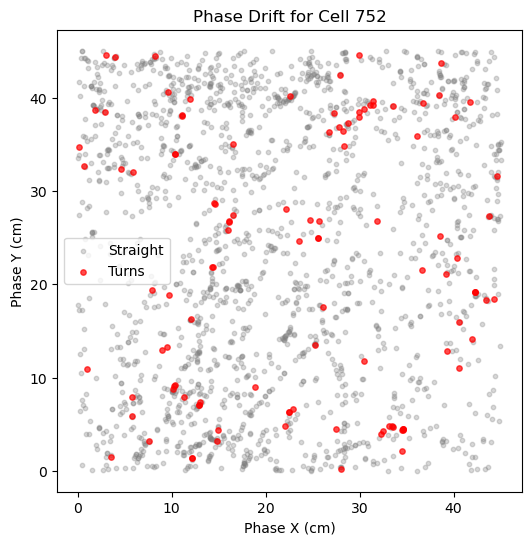

In [69]:
def plot_phase_drift(cell_id):
    # Retrieve phase data for a specific cell
    # (Assuming you saved the phase_x and phase_y arrays)
    

    rm = rate_map(x, y, t ,spikes_by_cell[cell_id]) 
    # print('rate map', rm.shape , rm)
    try:
        L, theta , _ = extract_grid_geometry(rm) 
        # print("FOUND ONE!")
    except Exception as e:
            print(f"Skipping Cell {cell_id}: Could not extract geometry. {e}")
            return 0
    phase_x = (x_smooth * np.cos(theta) + y_smooth * np.sin(theta)) % L
    phase_y = (x_smooth * np.cos(theta + np.pi/3) + y_smooth * np.sin(theta + np.pi/3)) % L



    phi1, phi2 = get_2d_phase(x_smooth, y_smooth, L, theta)
    spk_idx = np.searchsorted(t, spike_times)
    spk_phi1 = phi1[spk_idx]
    spk_phi2 = phi2[spk_idx]

    # Separate them
    turning_phi1 = spk_phi1[high_omega_mask[spk_idx]]
    turning_phi2 = spk_phi2[high_omega_mask[spk_idx]]

    straight_phi1 = spk_phi1[low_omega_mask[spk_idx]]
    straight_phi2 = spk_phi2[low_omega_mask[spk_idx]]



    r_straight = calculate_phase_coherence(straight_phi1, straight_phi2)
    r_turn = calculate_phase_coherence(turning_phi1, turning_phi2)



    plt.figure(figsize=(6, 6))
    
    # Plot straight spikes in gray
    plt.scatter(phase_x[spk_idx[low_omega_mask[spk_idx]]], 
                phase_y[spk_idx[low_omega_mask[spk_idx]]], 
                c='gray', alpha=0.3, s=10, label='Straight')
    
    # Overlay turning spikes in red
    plt.scatter(phase_x[spk_idx[high_omega_mask[spk_idx]]], 
                phase_y[spk_idx[high_omega_mask[spk_idx]]], 
                c='red', alpha=0.7, s=15, label='Turns')
    
    plt.title(f'Phase Drift for Cell {cell_id}')
    plt.xlabel('Phase X (cm)')
    plt.ylabel('Phase Y (cm)')
    plt.legend()
    plt.show()

# Visualize a sample cell
plot_phase_drift(list(cell_stats.keys())[10])

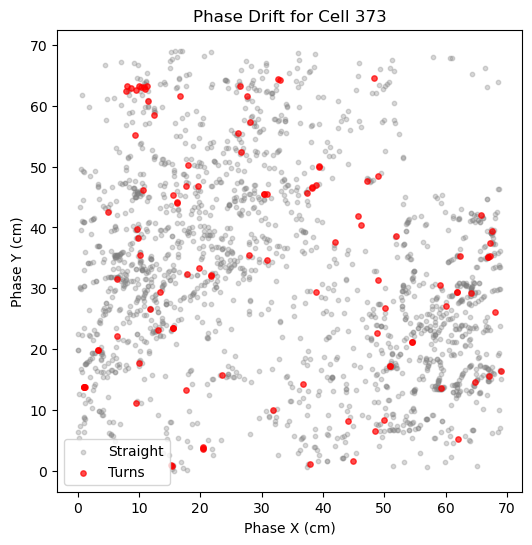

In [64]:
plot_phase_drift(list(cell_stats.keys())[130])

# dark

In [2]:
RAT_ID = 2

LIGHTING = "dark"

rat = RAT(n=RAT_ID, lighting=LIGHTING, filter_speed=False)

t = rat.T # (s), starts at 0

x = rat.X # (cm)

y = rat.Y # (cm)


v = rat.V # (cm/s)

spikes_by_cell = {}

spikes_by_cell.update(rat.grid_mod1)

spikes_by_cell.update(rat.grid_mod2)

spikes_by_cell.update(rat.grid_mod3) 

In [4]:
dx = np.gradient(x)
dy = np.gradient(y)

sigma_smoothing = 2
x_smooth = gaussian_filter1d(x, sigma=sigma_smoothing)
y_smooth = gaussian_filter1d(y, sigma=sigma_smoothing)

# 2. Recalculate dx, dy from smoothed data
dx_s = np.gradient(x_smooth)
dy_s = np.gradient(y_smooth)

# 3. Recalculate angle and unwrap
move_angle_s = np.unwrap(np.arctan2(dy_s, dx_s))

# 4. Calculate omega from the smoothed angle
dt = np.median(np.diff(t))
omega_fixed = np.abs(np.gradient(move_angle_s) / dt)

# Apply a small median filter to omega itself just to be safe
omega_fixed = median_filter(omega_fixed, size=3)

# 5. Mask for movement only (Speed > 3 cm/s)
speed_mask = v > 3

omega_threshold = np.percentile(omega_fixed, 80) # Or a fixed value like 0.5

high_omega_mask = speed_mask & (omega_fixed > omega_threshold)
low_omega_mask = speed_mask & (omega_fixed <= omega_threshold)



In [14]:
from scipy.stats import circmean , circvar

cell_stats = {}

for cell_id, spike_times in spikes_by_cell.items():
    # 1. Get L and theta for this specific cell
    rm = rate_map(x, y, t ,spike_times) 
    # print('rate map', rm.shape , rm)
    try:
        L, theta , _ = extract_grid_geometry(rm) 
        # print("FOUND ONE!")
    # except Exception as e:
    #         print(f"Skipping Cell {cell_id}: Could not extract geometry. {e}")
    #         continue

    # 2. Project trajectory onto grid axes
    # This allows you to see if the 'spatial phase' shifts 
    # during high omega segments
    # phase_x = (x_smooth * np.cos(theta) + y_smooth * np.sin(theta)) % L
    # phase_y = (x_smooth * np.cos(theta + np.pi/3) + y_smooth * np.sin(theta + np.pi/3)) % L
    
    # # 3. Separate spikes by turning vs straight
    # spk_idx = np.searchsorted(t, spike_times)
    # turning_spikes = phase_x[spk_idx[high_omega_mask[spk_idx]]]
    # straight_spikes = phase_x[spk_idx[low_omega_mask[spk_idx]]]

    # Calculate 2D phases for all spikes
        phi1, phi2 = get_2d_phase(x_smooth, y_smooth, L, theta)
        spk_idx = np.searchsorted(t, spike_times)
        
        spk_phi1 = phi1[spk_idx]
        spk_phi2 = phi2[spk_idx]

        # Separate them
        turning_phi1 = spk_phi1[high_omega_mask[spk_idx]]
        turning_phi2 = spk_phi2[high_omega_mask[spk_idx]]

        straight_phi1 = spk_phi1[low_omega_mask[spk_idx]]
        straight_phi2 = spk_phi2[low_omega_mask[spk_idx]]



        r_straight = calculate_phase_coherence(straight_phi1, straight_phi2)
        r_turn = calculate_phase_coherence(turning_phi1, turning_phi2)
        
        cell_stats[cell_id] = {
            'L': L,
            'theta': theta,
            'drift_metric': np.mean(r_turn) - np.mean(r_straight)}
    except Exception as e:
        print(e)
    

index 386517 is out of bounds for axis 0 with size 386517


/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
zero-size array to reduction operation minimum which has no identity
index 386517 is out of bounds for axis 0 with size 386517
zero-size array to reduction operation minimu

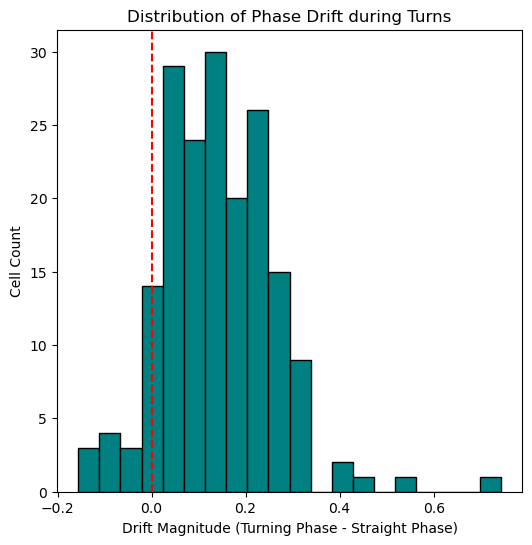

In [15]:
# Aggregate drift for all cells
all_drifts = [data['drift_metric'] for data in cell_stats.values()]

plt.figure(figsize=(6, 6))
plt.hist(all_drifts, bins=20, color='teal', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Phase Drift during Turns')
plt.xlabel('Drift Magnitude (Turning Phase - Straight Phase)')
plt.ylabel('Cell Count')
plt.show()